# RL vs `OrderUpToPolicy` — `09-rl-vs-baseline`

Loads the graph-engine-compatible PPO checkpoint (`actor_step0000005000.pt`,
94-dim observation, K_active=5) from `runs/rl_ppo/checkpoints/` and runs the
**CRN-paired evaluation harness** (`src.rl.eval.evaluate`) against `OrderUpToPolicy`.

> **The shipped checkpoint is smoke-trained (5 000 env steps).** Uplift is ~0
> or negative — the policy has not converged.  This notebook is a plumbing
> demonstration, not a performance claim.  To see meaningful uplift, re-run
> training with `--total-env-steps 1000000` (or more) and update `CHECKPOINT_PATH`.

**Why CRN?**  Each seed pair runs `OrderUpToPolicy` and the RL policy on
bit-identical `(world_seed, capacity, balance, active_subset, slot_permutation)`.
World variance cancels; any difference is attributable to the policy alone.
See [ADR 0003](../docs/adr/0003-crn-demand-for-all-products.md) and
[ADR 0007](../docs/adr/0007-rl-scale-invariance-package.md).

**Two resolutions in one place:**
1. Aggregate KPI / per-seed uplift (section 4).
2. Per-product single-seed overlay (section 5).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.rl.agents.ppo import Actor
from src.rl.configs.default import RLConfig
from src.rl.encoders import observation_dim, action_dim
from src.rl.eval import build_eval_seeds, evaluate
from src.sim.policy import OrderUpToPolicy
from src.sim.world_loader import load_world

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 4)

## 1. Pick checkpoint and config

Edit `EXPERIMENT` and `CHECKPOINT_PATH` (or leave `None` to auto-pick the latest)
to switch to a different training run. `K_ACTIVE` must match the value used during
training (default 5).

In [2]:
# ── Editable top-of-notebook variables ───────────────────────────────────────
RUNS_ROOT = Path('runs')
EXPERIMENT = 'rl_ppo'          # folder name under RUNS_ROOT
CHECKPOINT_PATH: Path | None = None   # None → auto-pick latest in EXPERIMENT
K_ACTIVE = 5                   # must match training config
N_EVAL_SEEDS = 8               # seeds for the aggregate section (keep small for speed)
# ──────────────────────────────────────────────────────────────────────────────

ckpt_dir = RUNS_ROOT / EXPERIMENT / 'checkpoints'
assert ckpt_dir.exists(), (
    f'Checkpoint dir not found: {ckpt_dir}. '
    f'Run `uv run python -m src.rl.train --experiment-name {EXPERIMENT} ...` first.'
)

ckpts = sorted(ckpt_dir.glob('actor_step*.pt'))
assert ckpts, f'No checkpoints found under {ckpt_dir}.'

if CHECKPOINT_PATH is None:
    CHECKPOINT_PATH = ckpts[-1]  # most recent by filename sort

print(f'Available checkpoints:')
for p in ckpts:
    marker = ' ← selected' if p == CHECKPOINT_PATH else ''
    print(f'  {p.name}{marker}')

# RLConfig — override any knob that differs from your training run
config = RLConfig(K_active=K_ACTIVE, n_eval_seeds=N_EVAL_SEEDS)
obs_dim = observation_dim(K_ACTIVE)
act_dim = action_dim(K_ACTIVE)
print(f'\nobs_dim={obs_dim}, act_dim={act_dim}  (K_active={K_ACTIVE})')

Available checkpoints:
  actor_step0000005000.pt ← selected

obs_dim=94, act_dim=10  (K_active=5)


## 2. Load the actor

The smoke checkpoint is a 94-dim Actor trained for 5 000 steps on a synthetic catalog.
The `state_dict` loads into the same `Actor` architecture used during training.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
actor = Actor(obs_dim=obs_dim, act_dim=act_dim).to(device)
state = torch.load(CHECKPOINT_PATH, map_location=device)
actor_state = state.get('actor', state)  # unwrap wrapper dict if present
actor.load_state_dict(actor_state)
actor.eval()

def rl_policy_fn(obs_np: np.ndarray) -> np.ndarray:
    obs_t = torch.tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        action_t, _, _ = actor.get_action_and_log_prob(obs_t)
    return action_t.squeeze(0).cpu().numpy().astype(np.float32)

def baseline_factory():
    return OrderUpToPolicy()

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')

Loaded checkpoint: runs/rl_ppo/checkpoints/actor_step0000005000.pt


## 3. Build catalog and eval seeds

Resolution order: explicit world cache → archetype auto-lookup → synthetic fallback.
The RL training used a synthetic catalog by default, so this notebook also falls back
to synthetic when no world cache is present.  Using the same catalog as training
ensures the eval distribution matches the training distribution.

In [4]:
catalog, base_template, world_market_params, disruption_params = load_world(
    archetype='rl_train',
    cache_path=None,
    delivery_lag=config.delivery_lag,
    holding_rate=config.holding_rate,
    order_fee=config.order_fee,
    K_active=config.K_active,
    synthetic_fallback=True,
    synthetic_catalog_size=config.K_catalog,
)

eval_specs = build_eval_seeds(
    catalog, base_template, config,
    market_params=world_market_params,
    disruption_params=disruption_params,
)

print(f'Catalog: {len(catalog)} products  (K_active={config.K_active})')
print(f'Eval seeds: {len(eval_specs)} (seed range '
      f'[{config.eval_seed_offset}, {config.eval_seed_offset + config.n_eval_seeds}))')

Catalog: 100 products  (K_active=5)
Eval seeds: 8 (seed range [10000000, 10000008))


[sim.world_loader] No world cache found at data/worlds/rl_train/world.json. Generating a synthetic catalog (no LLM calls).
[sim.world_loader] Synthetic catalog: 100 products.


## 4. Aggregate KPI / per-seed uplift

**Note:** the smoke-trained checkpoint (5 000 steps) has not converged; uplift is
expected to be ~0 or negative.  These cells demonstrate the evaluation plumbing,
not a performance result.

In [5]:
metrics = evaluate(
    rl_policy_fn=rl_policy_fn,
    baseline_policy_factory=baseline_factory,
    eval_specs=eval_specs,
    config=config,
)

# Pretty-print aggregate KPI table
kpi_rows = []
for key, val in sorted(metrics.items()):
    kpi_rows.append({'metric': key, 'value': val})
kpi_df = pd.DataFrame(kpi_rows)
print('Aggregate KPIs:')
display(kpi_df.style.format({'value': '{:.4f}'}))

Aggregate KPIs:


,metric,value
0,eval/baseline_inventory_turnover,0.0000
1,eval/baseline_mean_price_pct_of_msrp,1.0000
2,eval/baseline_net_profit,134487.0000
3,eval/baseline_return,134487.0000
4,eval/baseline_revenue,134487.0000
5,eval/baseline_service_level,0.0000
6,eval/baseline_stockout_rate,0.0000
7,eval/paired_uplift,-88034.3750
8,eval/rl_inventory_turnover,0.0000
9,eval/rl_mean_price_pct_of_msrp,1.0000


Mean uplift: -87619.50   Win rate: 0.0%   (smoke-trained checkpoint — uplift ~0 or negative is expected)


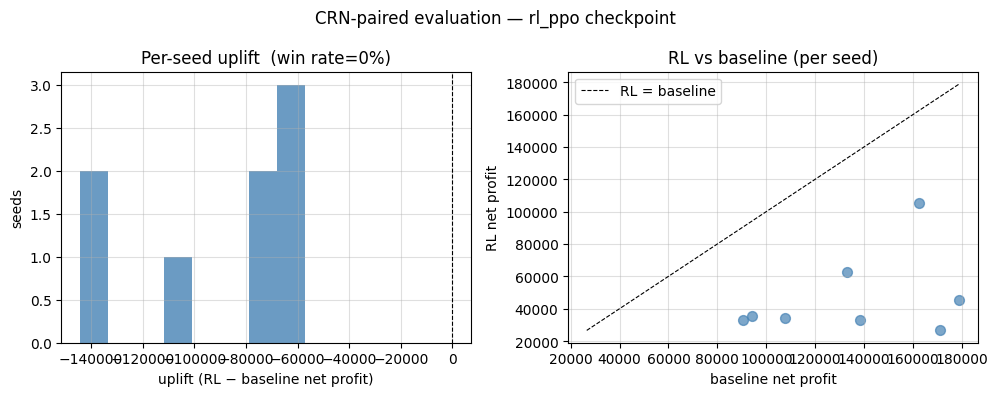

In [6]:
# Per-seed uplift: re-run evaluate per spec to get per-seed detail
from src.rl.eval import _run_rl, _run_baseline

seed_rows = []
for i, spec in enumerate(eval_specs):
    rl_m = _run_rl(rl_policy_fn, spec, config=config)
    bl_m = _run_baseline(baseline_factory(), spec, config=config)
    uplift = rl_m['net_profit'] - bl_m['net_profit']
    seed_rows.append({
        'seed_idx': i,
        'world_seed': spec.world_seed,
        'rl_net_profit': rl_m['net_profit'],
        'baseline_net_profit': bl_m['net_profit'],
        'uplift': uplift,
    })

seed_df = pd.DataFrame(seed_rows)
win_rate = (seed_df['uplift'] >= 0).mean()
mean_uplift = seed_df['uplift'].mean()
print(f'Mean uplift: {mean_uplift:+.2f}   Win rate: {win_rate:.1%}   '
      f'(smoke-trained checkpoint — uplift ~0 or negative is expected)')

# Uplift histogram
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].hist(seed_df['uplift'], bins=min(len(seed_df), 8), color='steelblue', alpha=0.8)
axes[0].set_xlabel('uplift (RL − baseline net profit)')
axes[0].set_ylabel('seeds')
axes[0].set_title(f'Per-seed uplift  (win rate={win_rate:.0%})')
axes[0].grid(True, alpha=0.4)

# Scatter on 45° line
axes[1].scatter(seed_df['baseline_net_profit'], seed_df['rl_net_profit'],
               alpha=0.7, s=50, color='steelblue')
lims = [min(seed_df[['rl_net_profit', 'baseline_net_profit']].min()),
        max(seed_df[['rl_net_profit', 'baseline_net_profit']].max())]
axes[1].plot(lims, lims, 'k--', linewidth=0.8, label='RL = baseline')
axes[1].set_xlabel('baseline net profit')
axes[1].set_ylabel('RL net profit')
axes[1].set_title('RL vs baseline (per seed)')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle(f'CRN-paired evaluation — {EXPERIMENT} checkpoint', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Per-product single-seed overlay

Runs the RL policy and `OrderUpToPolicy` on a single held-out seed and plots
inventory, orders, and net profit per active product side-by-side.  This gives
a tick-by-tick view of how the two policies behave on identical world dynamics.

In [7]:
from collections import deque
from src.rl.encoders import encode_observation, decode_action, compute_effective_rate
from src.rl.episode_sampler import sample_episode
from src.sim.policy import RLIntermediatePolicy
from src.sim.runner import build_world

# Use the first eval seed for the overlay
spec = eval_specs[0]
K = config.K_active
active_subset = spec.active_subset
slot_perm = spec.slot_permutation
supplier_ids_for = {pid: [f'F_{pid}'] for pid in active_subset}

# ── RL policy run ──────────────────────────────────────────────────────────────
rl_policy = RLIntermediatePolicy()
sim_rl = build_world(spec.scenario, policy_overrides={'S': rl_policy})
node_rl = sim_rl.nodes['S']
initial_cash = float(node_rl.cash)
sales_history: dict[str, deque] = {pid: deque(maxlen=100) for pid in active_subset}
base_prices = {pid: float(node_rl.list_prices.get(pid, 1.0)) for pid in active_subset}

from src.sim.distributions import Distribution as _Distribution
from random import Random as _Random
market_base_demand = getattr(spec.scenario.market, 'base_demand', None)
if isinstance(market_base_demand, _Distribution):
    prior_rng = _Random(spec.world_seed + 1)
    base_demand_prior = float(market_base_demand.sample(prior_rng))
elif market_base_demand is not None:
    base_demand_prior = float(market_base_demand)
else:
    base_demand_prior = 1.0

rl_inv_trace: dict[str, list] = {pid: [] for pid in active_subset}
rl_cash_trace: list[float] = []

for tick in range(spec.scenario.n_steps):
    current_tick = sim_rl.tick_world()
    central_table = getattr(sim_rl, '_current_table', None)
    effective_rate = compute_effective_rate(sales_history, base_demand_prior)
    obs = encode_observation(
        node=node_rl, market=sim_rl.market,
        registry=sim_rl.item_registry, step=tick,
        slot_perm=slot_perm, K_active=K,
        central_table=central_table,
        active_subset=active_subset,
        supplier_ids_for=supplier_ids_for,
        initial_cash=initial_cash, sales_history=sales_history,
        effective_rate=effective_rate,
    )
    action_vec = rl_policy_fn(obs)
    all_supplier_ids = [f'F_{pid}' for pid in active_subset]
    action_dict = decode_action(
        np.asarray(action_vec, dtype=np.float32), slot_perm, node_rl,
        K, base_prices, supplier_ids=all_supplier_ids,
        active_subset=active_subset, effective_rate=effective_rate,
        target_centre_lead_times=config.target_centre_lead_times,
        target_half_span_lead_times=config.target_half_span_lead_times,
        target_max_lead_times=config.target_max_lead_times,
    )
    rl_policy.set_pending_action(action_dict)
    sim_rl.tick_decide_and_settle(current_tick)
    last_sales = sim_rl._last_tick_sales.get('S', {})
    for pid in active_subset:
        sales_history[pid].append(last_sales.get(pid, 0))
        rl_inv_trace[pid].append(node_rl.inventory.get(pid, 0))
    rl_cash_trace.append(float(node_rl.cash))

# ── Baseline run ───────────────────────────────────────────────────────────────
bl_policy = baseline_factory()
sim_bl = build_world(spec.scenario, policy_overrides={'S': bl_policy})
node_bl = sim_bl.nodes['S']
bl_inv_trace: dict[str, list] = {pid: [] for pid in active_subset}
bl_cash_trace: list[float] = []

for tick in range(spec.scenario.n_steps):
    sim_bl.tick()
    for pid in active_subset:
        bl_inv_trace[pid].append(node_bl.inventory.get(pid, 0))
    bl_cash_trace.append(float(node_bl.cash))

print(f'Single-seed run complete (world_seed={spec.world_seed}, '
      f'{spec.scenario.n_steps} ticks, {K} active SKUs)')

Single-seed run complete (world_seed=1345003908, 180 ticks, 5 active SKUs)


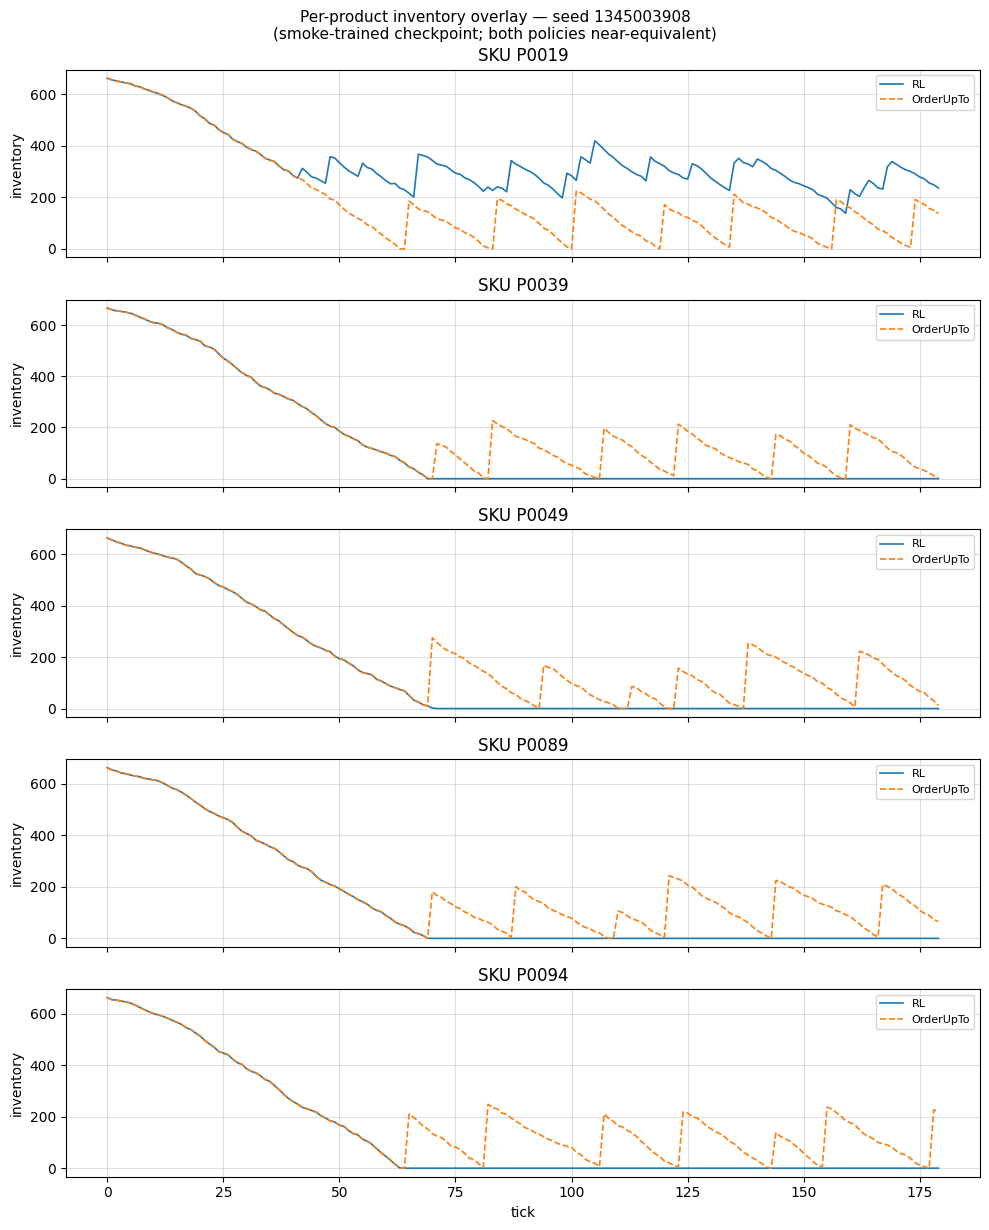

In [8]:
ticks = np.arange(spec.scenario.n_steps)
n_products = len(active_subset)

# Per-product inventory overlay
fig, axes = plt.subplots(n_products, 1, figsize=(10, 2.5 * n_products), sharex=True)
if n_products == 1:
    axes = [axes]
for ax, pid in zip(axes, active_subset):
    ax.plot(ticks, rl_inv_trace[pid], label='RL', linewidth=1.2)
    ax.plot(ticks, bl_inv_trace[pid], label='OrderUpTo', linewidth=1.2, linestyle='--')
    ax.set_ylabel('inventory')
    ax.set_title(f'SKU {pid}')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.4)
axes[-1].set_xlabel('tick')
fig.suptitle(
    f'Per-product inventory overlay — seed {spec.world_seed}\n'
    f'(smoke-trained checkpoint; both policies near-equivalent)',
    fontsize=11
)
plt.tight_layout()
plt.show()

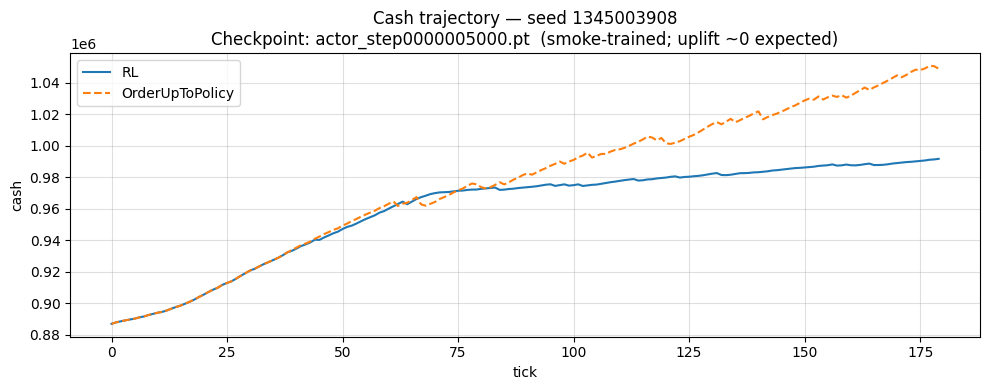

In [9]:
# Cash traces
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ticks, rl_cash_trace, label='RL', linewidth=1.5)
ax.plot(ticks, bl_cash_trace, label='OrderUpToPolicy', linewidth=1.5, linestyle='--')
ax.set_xlabel('tick')
ax.set_ylabel('cash')
ax.set_title(
    f'Cash trajectory — seed {spec.world_seed}\n'
    f'Checkpoint: {CHECKPOINT_PATH.name}  (smoke-trained; uplift ~0 expected)'
)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()